# Joint Photometry + Spectroscopy: The Full Picture

Broadband photometry constrains the overall SED shape -- stellar mass,
dust attenuation, and redshift -- but cannot break the age-dust-metallicity
degeneracy. Spectroscopy resolves individual absorption and emission
features that pin down stellar ages and chemical enrichment, yet covers
a limited wavelength range. Joint fitting exploits both: photometry
anchors the broadband continuum while spectroscopy supplies the fine
detail, yielding tighter posteriors than either dataset alone.

This notebook demonstrates the `Observation` class for joint fitting
in tengri: constructing a joint observation, generating mock data,
running MAP inference, and comparing constraints from photometry-only,
spectroscopy-only, and joint fits.

In [1]:
import os
import sys
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

# Path setup for data/ and _plot_style
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))

if os.path.exists("data"):
    pass
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("fitting", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

## Creating a Joint Observation

The `Observation` class bundles photometry and spectroscopy into a single
declarative object. Pass `Photometry` for broadband filters and
`Spectroscopy` for the wavelength grid and instrument settings.
The model will produce predictions for both in a single forward pass.

In [3]:
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)

obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=100),
)

print(obs.summary())
print(f"\nis_joint: {obs.is_joint}")
print(f"n_data:   {obs.n_data}  ({obs.n_data_phot} phot + {obs.n_data_spec} spec)")

Observation
--------------------------------------------------
  Photometry : 5 filters: sdss_u, sdss_g, sdss_r, sdss_i, sdss_z
  Spectroscopy : 200 pixels, R=100
  Data type  : joint
  N data     : 205
               (5 phot + 200 spec)

is_joint: True
n_data:   205  (5 phot + 200 spec)


## Generate Joint Mock Data

We create a `Model` with the joint observation and generate mock
photometry and spectroscopy from a known truth. The same forward model
parameters produce both data vectors simultaneously.

In [4]:
spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)

model = Model(spec, ssp_data, observation=obs)

key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
# Override to a typical star-forming galaxy
true_params = {
    **true_params,
    "sfh_tsnorm_log_peak_sfr": jnp.array(1.2),
    "sfh_tsnorm_peak_lbt_gyr": jnp.array(3.0),
    "sfh_tsnorm_width_gyr": jnp.array(3.0),
    "sfh_tsnorm_skew": jnp.array(0.3),
    "sfh_tsnorm_trunc": jnp.array(2.0),
}

# Generate mock photometry and spectrum separately, then pack
k1, k2 = jax.random.split(key)
mock_phot = model.mock(true_params, snr=20.0, key=k1)
mock_spec = model.mock_spectrum(true_params, WAVE_OBS, snr=30.0, key=k2)

# Pack into joint data vector using Observation
data_joint = obs.pack_data(phot=mock_phot.flux_obs, spec=mock_spec.flux_obs)
noise_joint = obs.pack_data(phot=mock_phot.noise, spec=mock_spec.noise)

print(f"Joint data vector shape: {data_joint.shape}")

W0405 02:37:09.323931 36243644 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_78826/525029568.py:15: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, observation=obs)


<local>/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


Joint data vector shape: (205,)


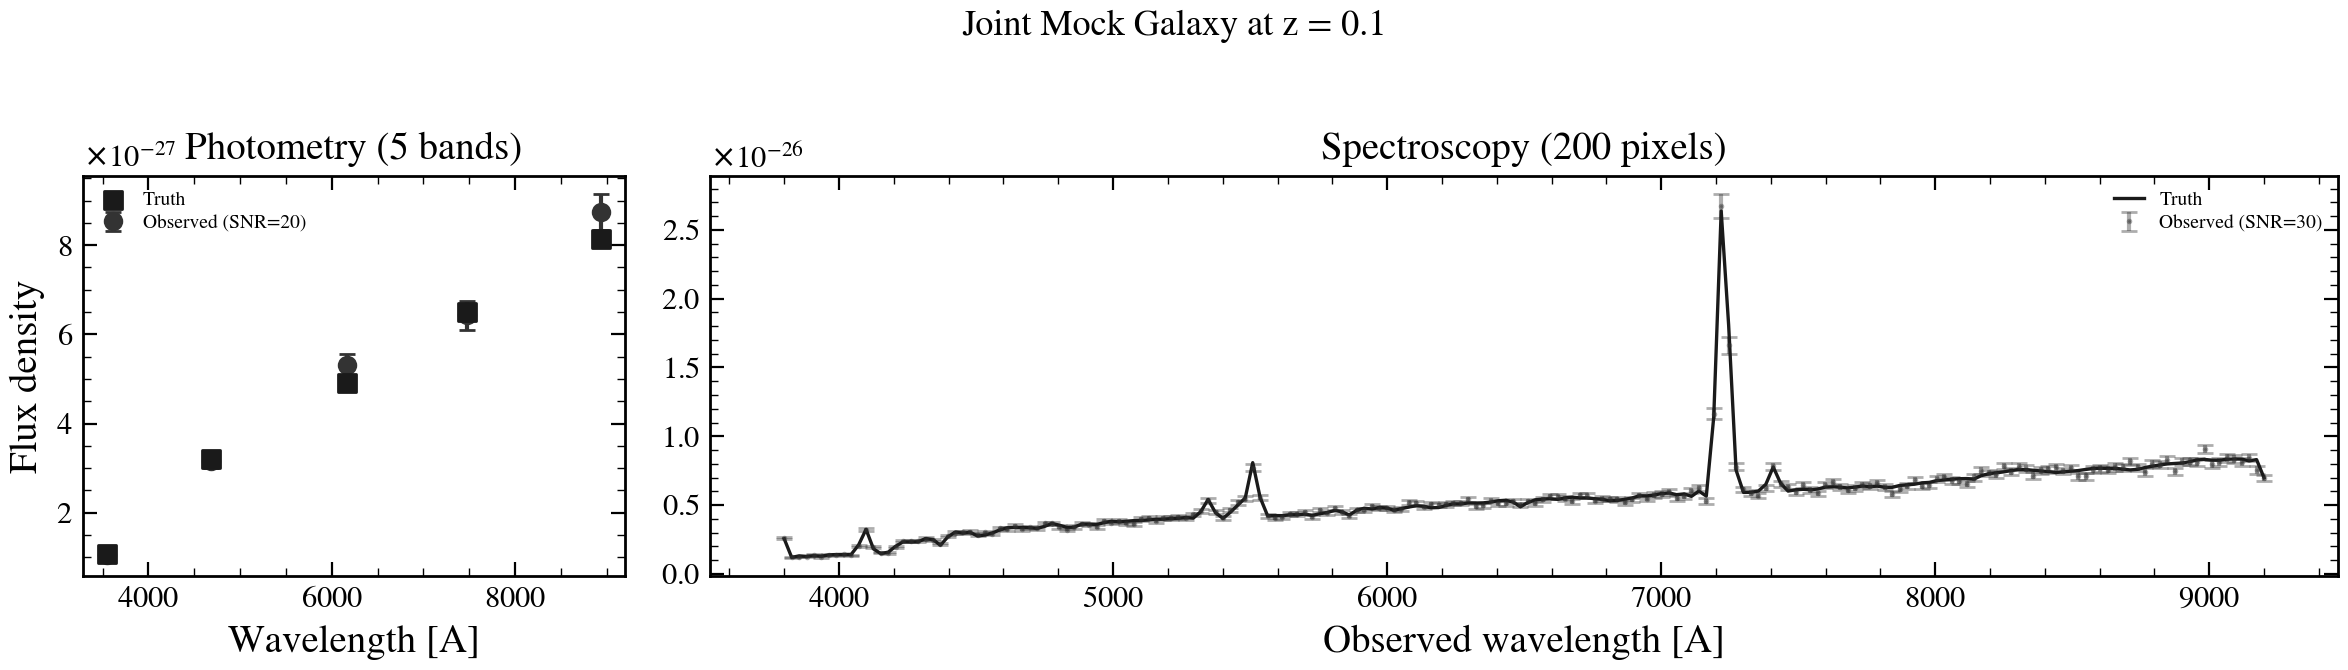

In [5]:
# --- FIGURE 1: Two-panel mock data ---
fig, (ax_p, ax_s) = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 3]})

# Photometry panel
wave_eff = np.array([3551, 4686, 6166, 7480, 8932])  # SDSS effective wavelengths
ax_p.errorbar(
    wave_eff,
    np.array(mock_phot.flux_obs),
    yerr=np.array(mock_phot.noise),
    fmt="o",
    ms=6,
    color=COLORS["data"],
    label="Observed (SNR=20)",
)
ax_p.scatter(
    wave_eff,
    np.array(mock_phot.flux_true),
    marker="s",
    s=40,
    color=COLORS["truth"],
    zorder=5,
    label="Truth",
)
ax_p.set_xlabel("Wavelength [A]")
ax_p.set_ylabel("Flux density")
ax_p.set_title("Photometry (5 bands)")
ax_p.legend(fontsize=7)

# Spectrum panel
w = np.array(WAVE_OBS)
ax_s.errorbar(
    w,
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.4,
    label="Observed (SNR=30)",
)
ax_s.plot(w, np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1.2, label="Truth")
ax_s.set_xlabel("Observed wavelength [A]")
ax_s.set_title("Spectroscopy (200 pixels)")
ax_s.legend(fontsize=7)

fig.suptitle("Joint Mock Galaxy at z = 0.1", fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_joint_mock_data.png"), dpi=150, bbox_inches="tight")
plt.show()

## Fit with MAP

The `Fitter` accepts the packed joint data vector. Because the `Model`
carries the `Observation`, the fitter automatically infers
`data_type="joint"` and dispatches the correct likelihood.

In [6]:
fitter = Fitter(model, data_joint, noise_joint)
print(f"Fitter data_type: {fitter.data_type}")
fitter.compile(verbose=False)

t0 = time.perf_counter()
result_map = fitter.run("map", n_steps=500, verbose=False)
t_fit = time.perf_counter() - t0
print(f"MAP fit completed in {t_fit:.1f}s")

Fitter data_type: joint


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:37:13.389780 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


MAP fit completed in 0.6s


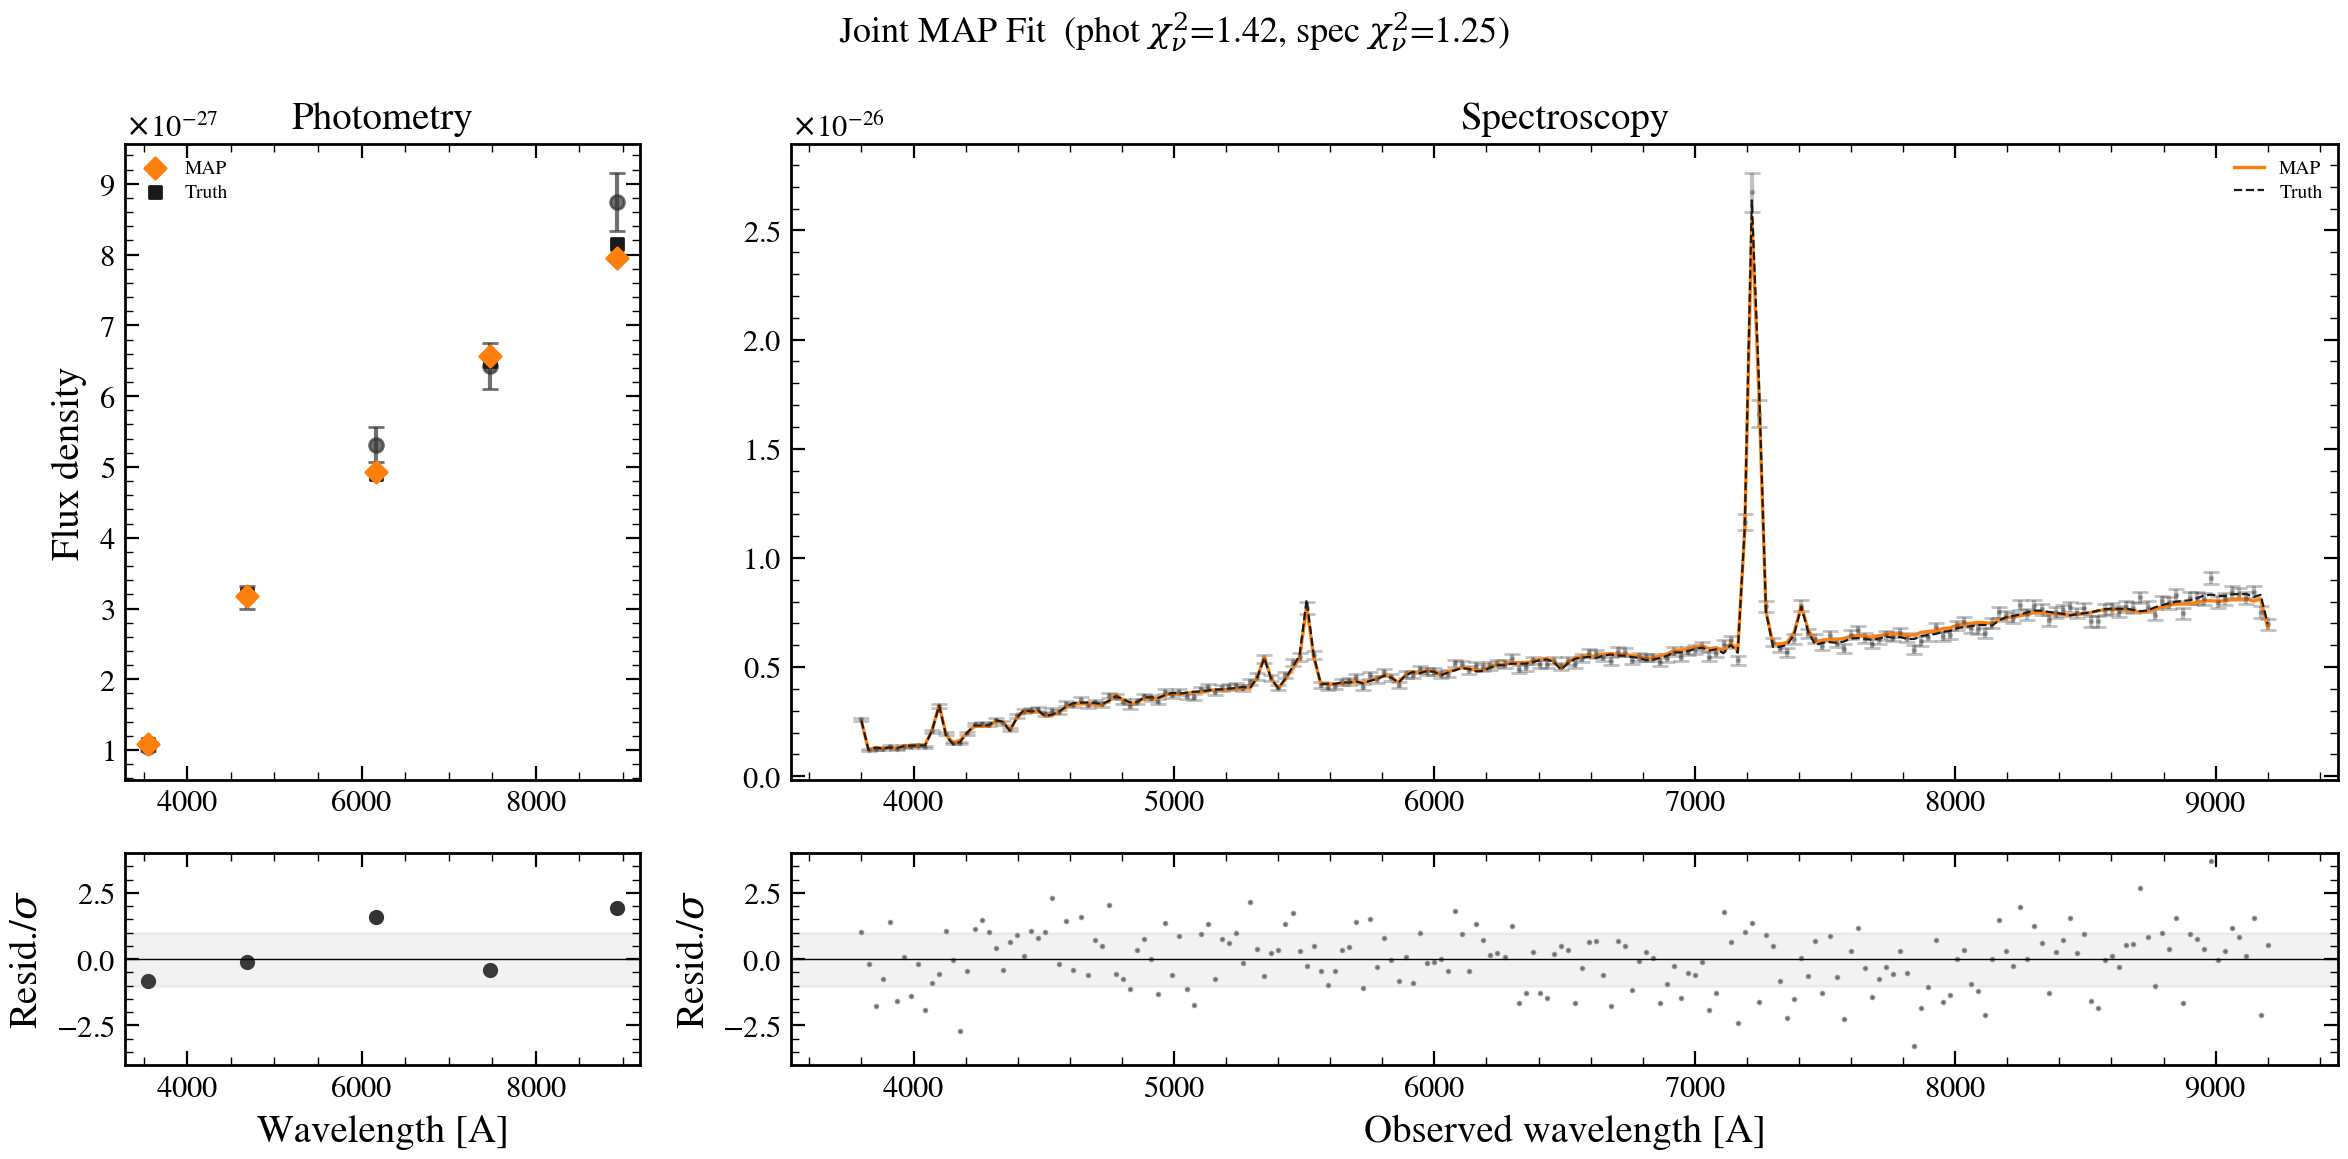

In [7]:
# --- FIGURE 2: Joint fit quality (photometry + spectrum + residuals) ---
map_params = result_map.best_fit if hasattr(result_map, "best_fit") else result_map.params

pred_phot = np.array(model.predict_photometry(map_params))
pred_spec = np.array(model.predict_spectrum(map_params))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 6),
    gridspec_kw={"height_ratios": [3, 1], "width_ratios": [1, 3]},
)
ax_p, ax_s = axes[0]
ax_pr, ax_sr = axes[1]

# Photometry fit
ax_p.errorbar(
    wave_eff,
    np.array(mock_phot.flux_obs),
    yerr=np.array(mock_phot.noise),
    fmt="o",
    ms=5,
    color=COLORS["data"],
    alpha=0.7,
)
ax_p.scatter(wave_eff, pred_phot, marker="D", s=30, color=COLORS["geovi"], zorder=5, label="MAP")
ax_p.scatter(
    wave_eff,
    np.array(mock_phot.flux_true),
    marker="s",
    s=20,
    color=COLORS["truth"],
    zorder=4,
    label="Truth",
)
ax_p.set_ylabel("Flux density")
ax_p.set_title("Photometry")
ax_p.legend(fontsize=7)

# Photometry residuals
res_p = (np.array(mock_phot.flux_obs) - pred_phot) / np.array(mock_phot.noise)
ax_pr.scatter(wave_eff, res_p, s=20, c=COLORS["data"])
ax_pr.axhline(0, color="k", lw=0.5)
ax_pr.axhspan(-1, 1, alpha=0.1, color="grey")
ax_pr.set_ylim(-4, 4)
ax_pr.set_xlabel("Wavelength [A]")
ax_pr.set_ylabel(r"Resid./$\sigma$")

# Spectrum fit
ax_s.errorbar(
    w,
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.3,
)
ax_s.plot(w, pred_spec, color=COLORS["geovi"], lw=1.2, label="MAP")
ax_s.plot(w, np.array(mock_spec.flux_true), color=COLORS["truth"], lw=0.8, ls="--", label="Truth")
ax_s.set_title("Spectroscopy")
ax_s.legend(fontsize=7)

# Spectrum residuals
res_s = (np.array(mock_spec.flux_obs) - pred_spec) / np.array(mock_spec.noise)
ax_sr.scatter(w, res_s, s=1, c=COLORS["data"], alpha=0.5)
ax_sr.axhline(0, color="k", lw=0.5)
ax_sr.axhspan(-1, 1, alpha=0.1, color="grey")
ax_sr.set_ylim(-4, 4)
ax_sr.set_xlabel("Observed wavelength [A]")
ax_sr.set_ylabel(r"Resid./$\sigma$")

chi2_p = np.sum(res_p**2) / len(res_p)
chi2_s = np.sum(res_s**2) / len(res_s)
fig.suptitle(
    f"Joint MAP Fit  (phot $\\chi^2_\\nu$={chi2_p:.2f}, spec $\\chi^2_\\nu$={chi2_s:.2f})",
    fontsize=13,
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_joint_map_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

## Comparing Constraints: Photometry vs Spectroscopy vs Joint

To see the advantage of joint fitting, we run three separate MAP fits
using the same model and truth but different data combinations. We
then compare the best-fit parameter errors.

In [8]:
# Photometry-only model and fit
obs_phot = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
)
model_phot = Model(spec, ssp_data, observation=obs_phot)
fitter_phot = Fitter(model_phot, mock_phot.flux_obs, mock_phot.noise)
fitter_phot.compile(verbose=False)
result_phot = fitter_phot.run("map", n_steps=500, verbose=False)

# Spectroscopy-only model and fit
obs_spec = Observation(
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=100),
)
model_spec = Model(spec, ssp_data, observation=obs_spec)
fitter_spec = Fitter(model_spec, mock_spec.flux_obs, mock_spec.noise)
fitter_spec.compile(verbose=False)
result_spec = fitter_spec.run("map", n_steps=500, verbose=False)

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_78826/3746007322.py:5: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_phot = Model(spec, ssp_data, observation=obs_phot)
assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


W0405 02:39:39.821023 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:39:41.563805 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:39:43.888571 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:39:50.930278 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:39:54.380264 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:39:55.591813 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)
assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


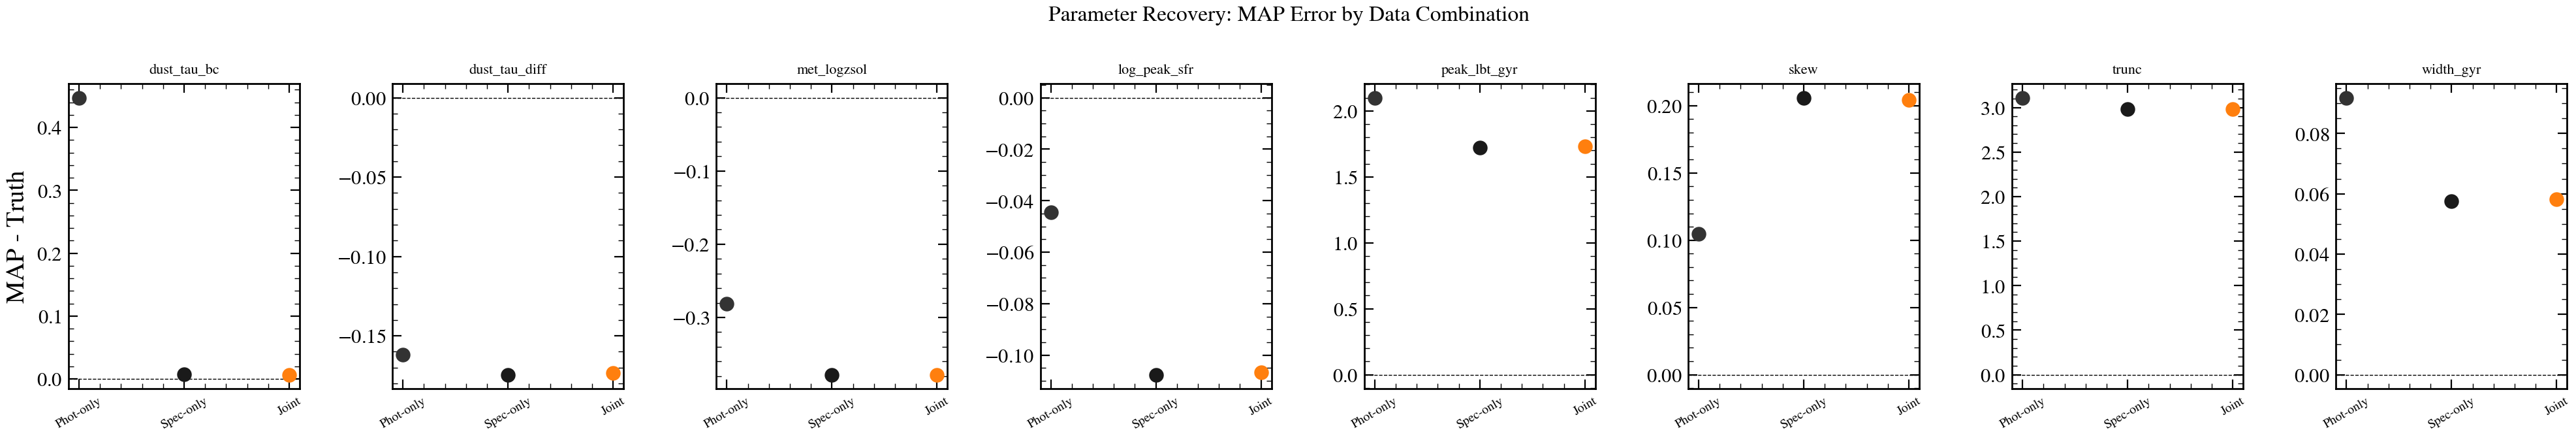

In [9]:
# --- FIGURE 3: Parameter recovery comparison ---
results = {
    "Phot-only": result_phot,
    "Spec-only": result_spec,
    "Joint": result_map,
}

param_names = spec.free_params
true_vals = {p: float(true_params[p]) for p in param_names}

fig, axes = plt.subplots(1, len(param_names), figsize=(2.5 * len(param_names), 3.5))
colors_list = [COLORS.get("data", "C0"), COLORS.get("truth", "C1"), COLORS.get("geovi", "C2")]

for i, pname in enumerate(param_names):
    ax = axes[i]
    tv = true_vals[pname]

    for j, (_label, res) in enumerate(results.items()):
        bf = res.best_fit if hasattr(res, "best_fit") else res.params
        val = float(bf[pname])
        ax.scatter(j, val - tv, s=50, color=colors_list[j], zorder=5)

    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels(list(results.keys()), fontsize=7, rotation=30)
    ax.set_title(pname.replace("sfh_tsnorm_", ""), fontsize=8)
    if i == 0:
        ax.set_ylabel("MAP - Truth")

fig.suptitle("Parameter Recovery: MAP Error by Data Combination", fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_constraint_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## Full Posterior Inference on Joint Data

MAP gives a single best-fit point but no uncertainty. Now we run three
posterior methods on the joint fitter: native_geovi, Laplace, Pathfinder.

In [10]:
k_post, k_lap, k_pf = jax.random.split(jax.random.PRNGKey(99), 3)

t0 = time.perf_counter()
result_geovi = fitter.run(
    "vi",
    key=k_post,
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=2000,
    verbose=False,
)
t_geovi = time.perf_counter() - t0

t0 = time.perf_counter()
result_laplace = fitter.run(
    "laplace",
    key=k_lap,
    init_from=result_map,
    n_samples=2000,
    verbose=False,
)
t_laplace = time.perf_counter() - t0

t0 = time.perf_counter()
result_pathfinder = fitter.run(
    "pathfinder",
    key=k_pf,
    n_samples=2000,
    maxiter=30,
    verbose=False,
)
t_pathfinder = time.perf_counter() - t0

print(f"native_geovi: {t_geovi:.1f}s")
print(f"Laplace:      {t_laplace:.1f}s")
print(f"Pathfinder:   {t_pathfinder:.1f}s")

W0405 02:44:40.785667 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


native_geovi: 192.6s
Laplace:      5.7s
Pathfinder:   10.6s


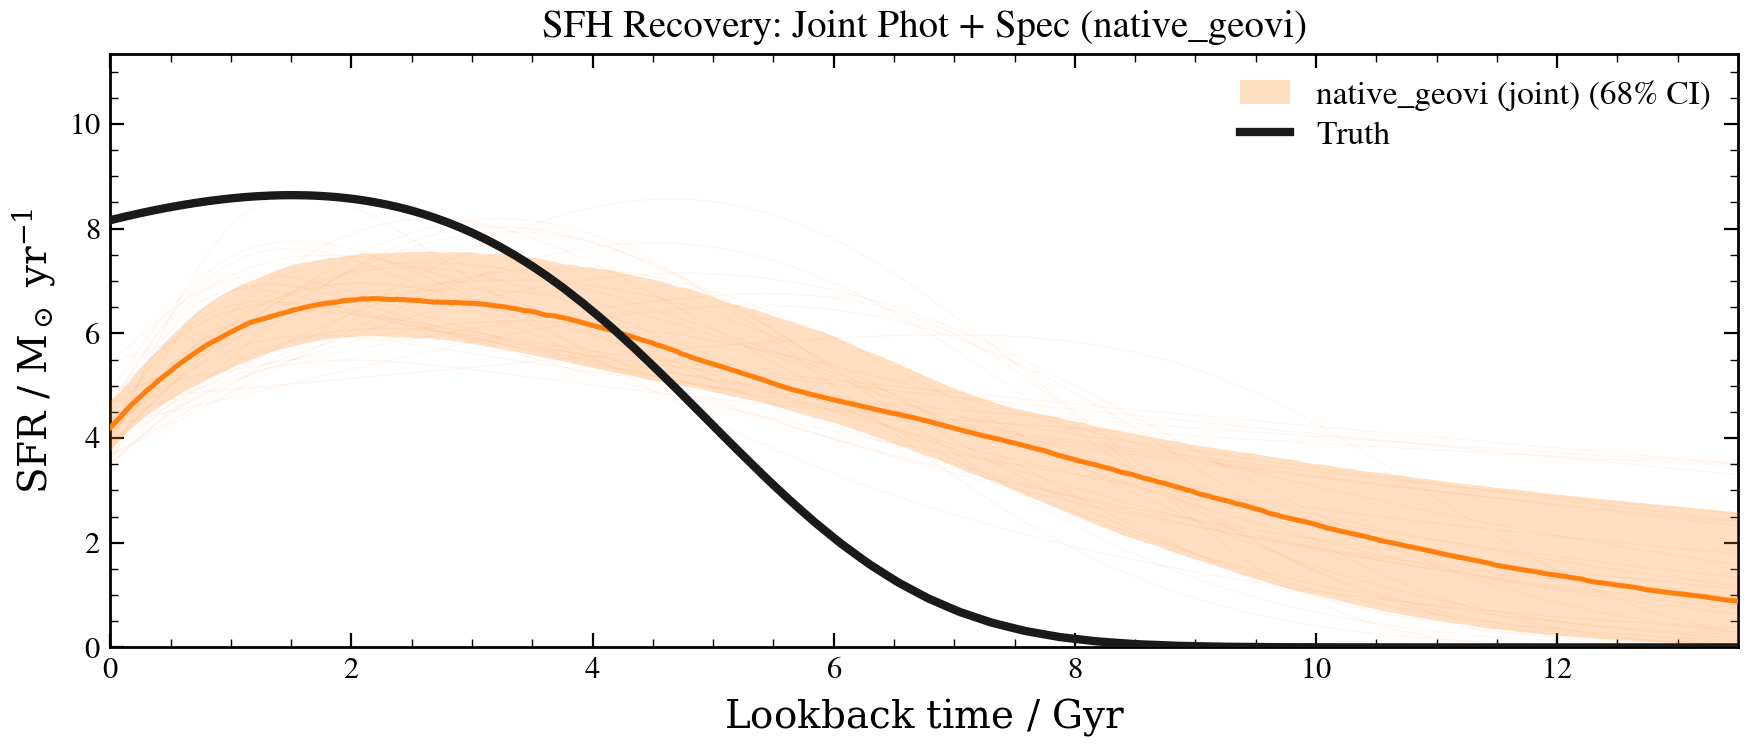

In [11]:
# --- SFH recovery from joint posterior ---
fig, ax = plt.subplots(figsize=(9, 4))
plot_sfh(
    model,
    result_geovi,
    true_params=true_params,
    ax=ax,
    color=COLORS["geovi"],
    label="native_geovi (joint)",
    method="geoVI",
)
ax.set_title("SFH Recovery: Joint Phot + Spec (native_geovi)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_sfh_joint.png"), dpi=150, bbox_inches="tight")
plt.show()

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

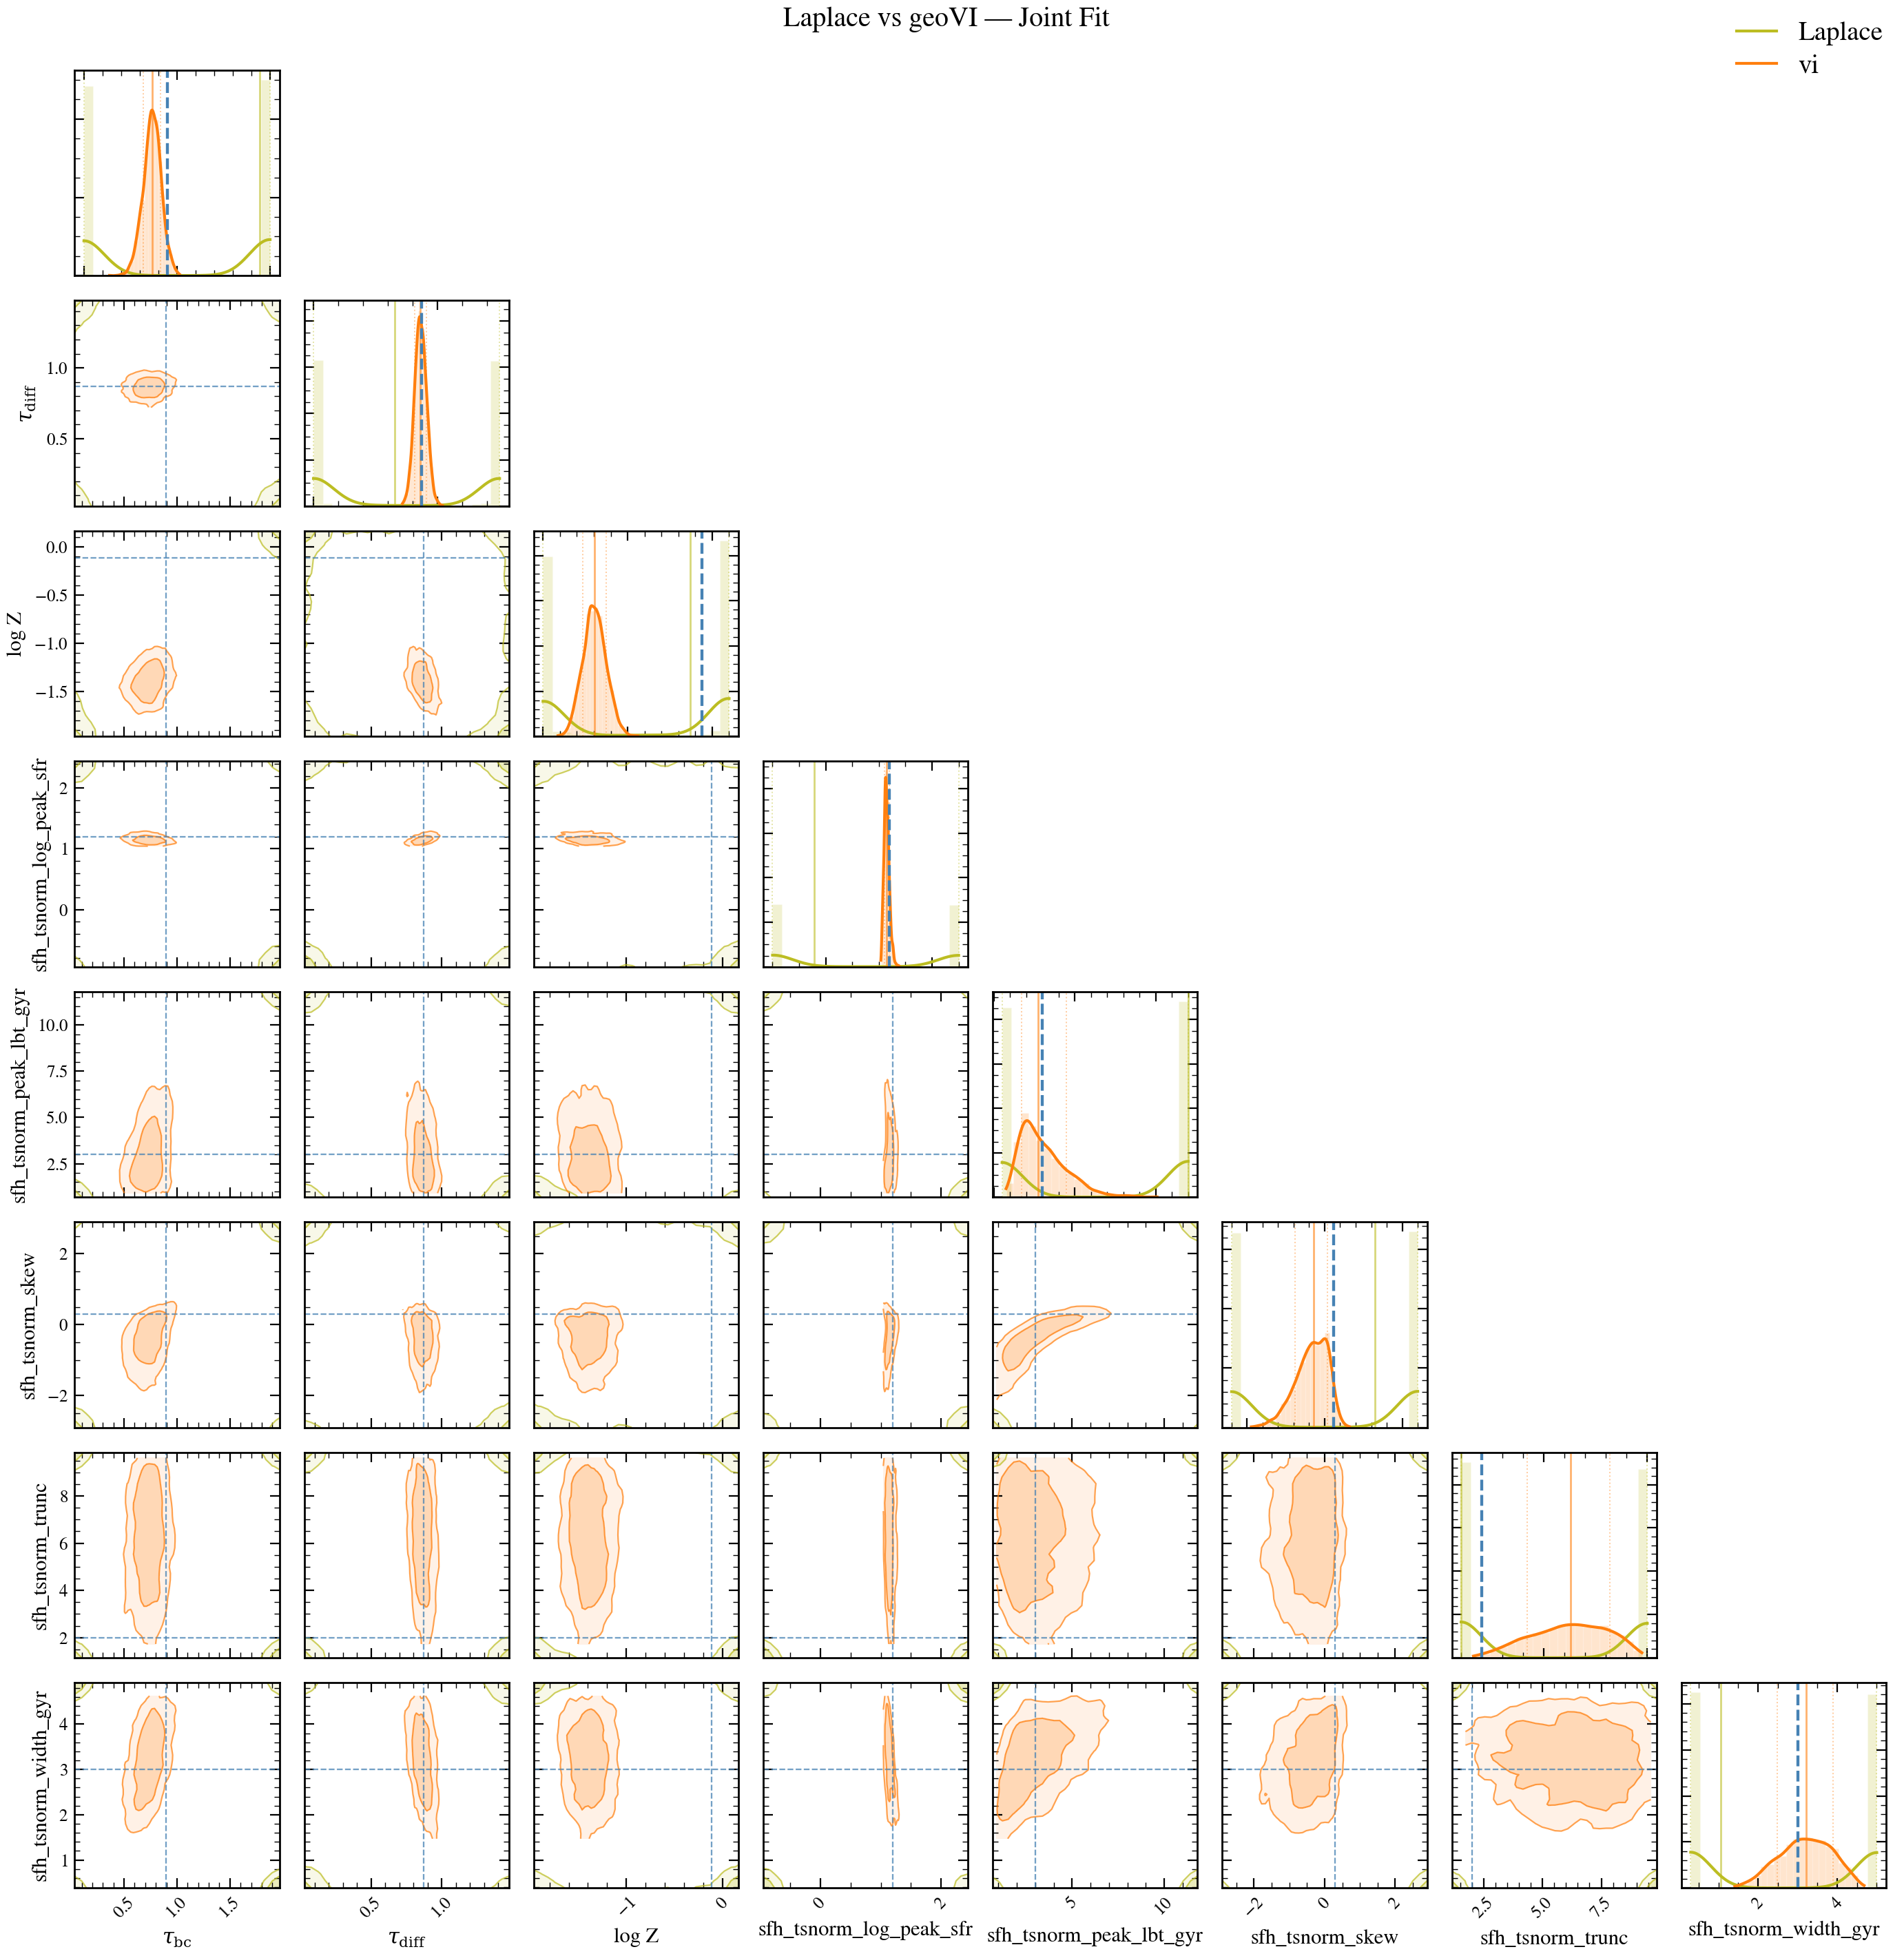

In [12]:
# --- Corner: Laplace vs geoVI (joint posteriors) ---
truths_dict = {p: float(true_params[p]) for p in spec.free_params}

fig = plot_corner_comparison(
    [result_laplace, result_geovi],
    labels=["Laplace", "vi"],
    colors=[COLORS["laplace"], COLORS["geovi"]],
    truths=truths_dict,
)
if fig is not None:
    fig.suptitle("Laplace vs geoVI — Joint Fit", y=1.02)
    plt.savefig(
        os.path.join(FIGDIR, "fig11_corner_laplace_vs_geovi.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

W0405 02:45:16.692880 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 2.7 ± 0.5 (CV=18%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


W0405 02:45:25.493962 36243508 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=7.3 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 136.9 ± 49.8 (CV=36%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

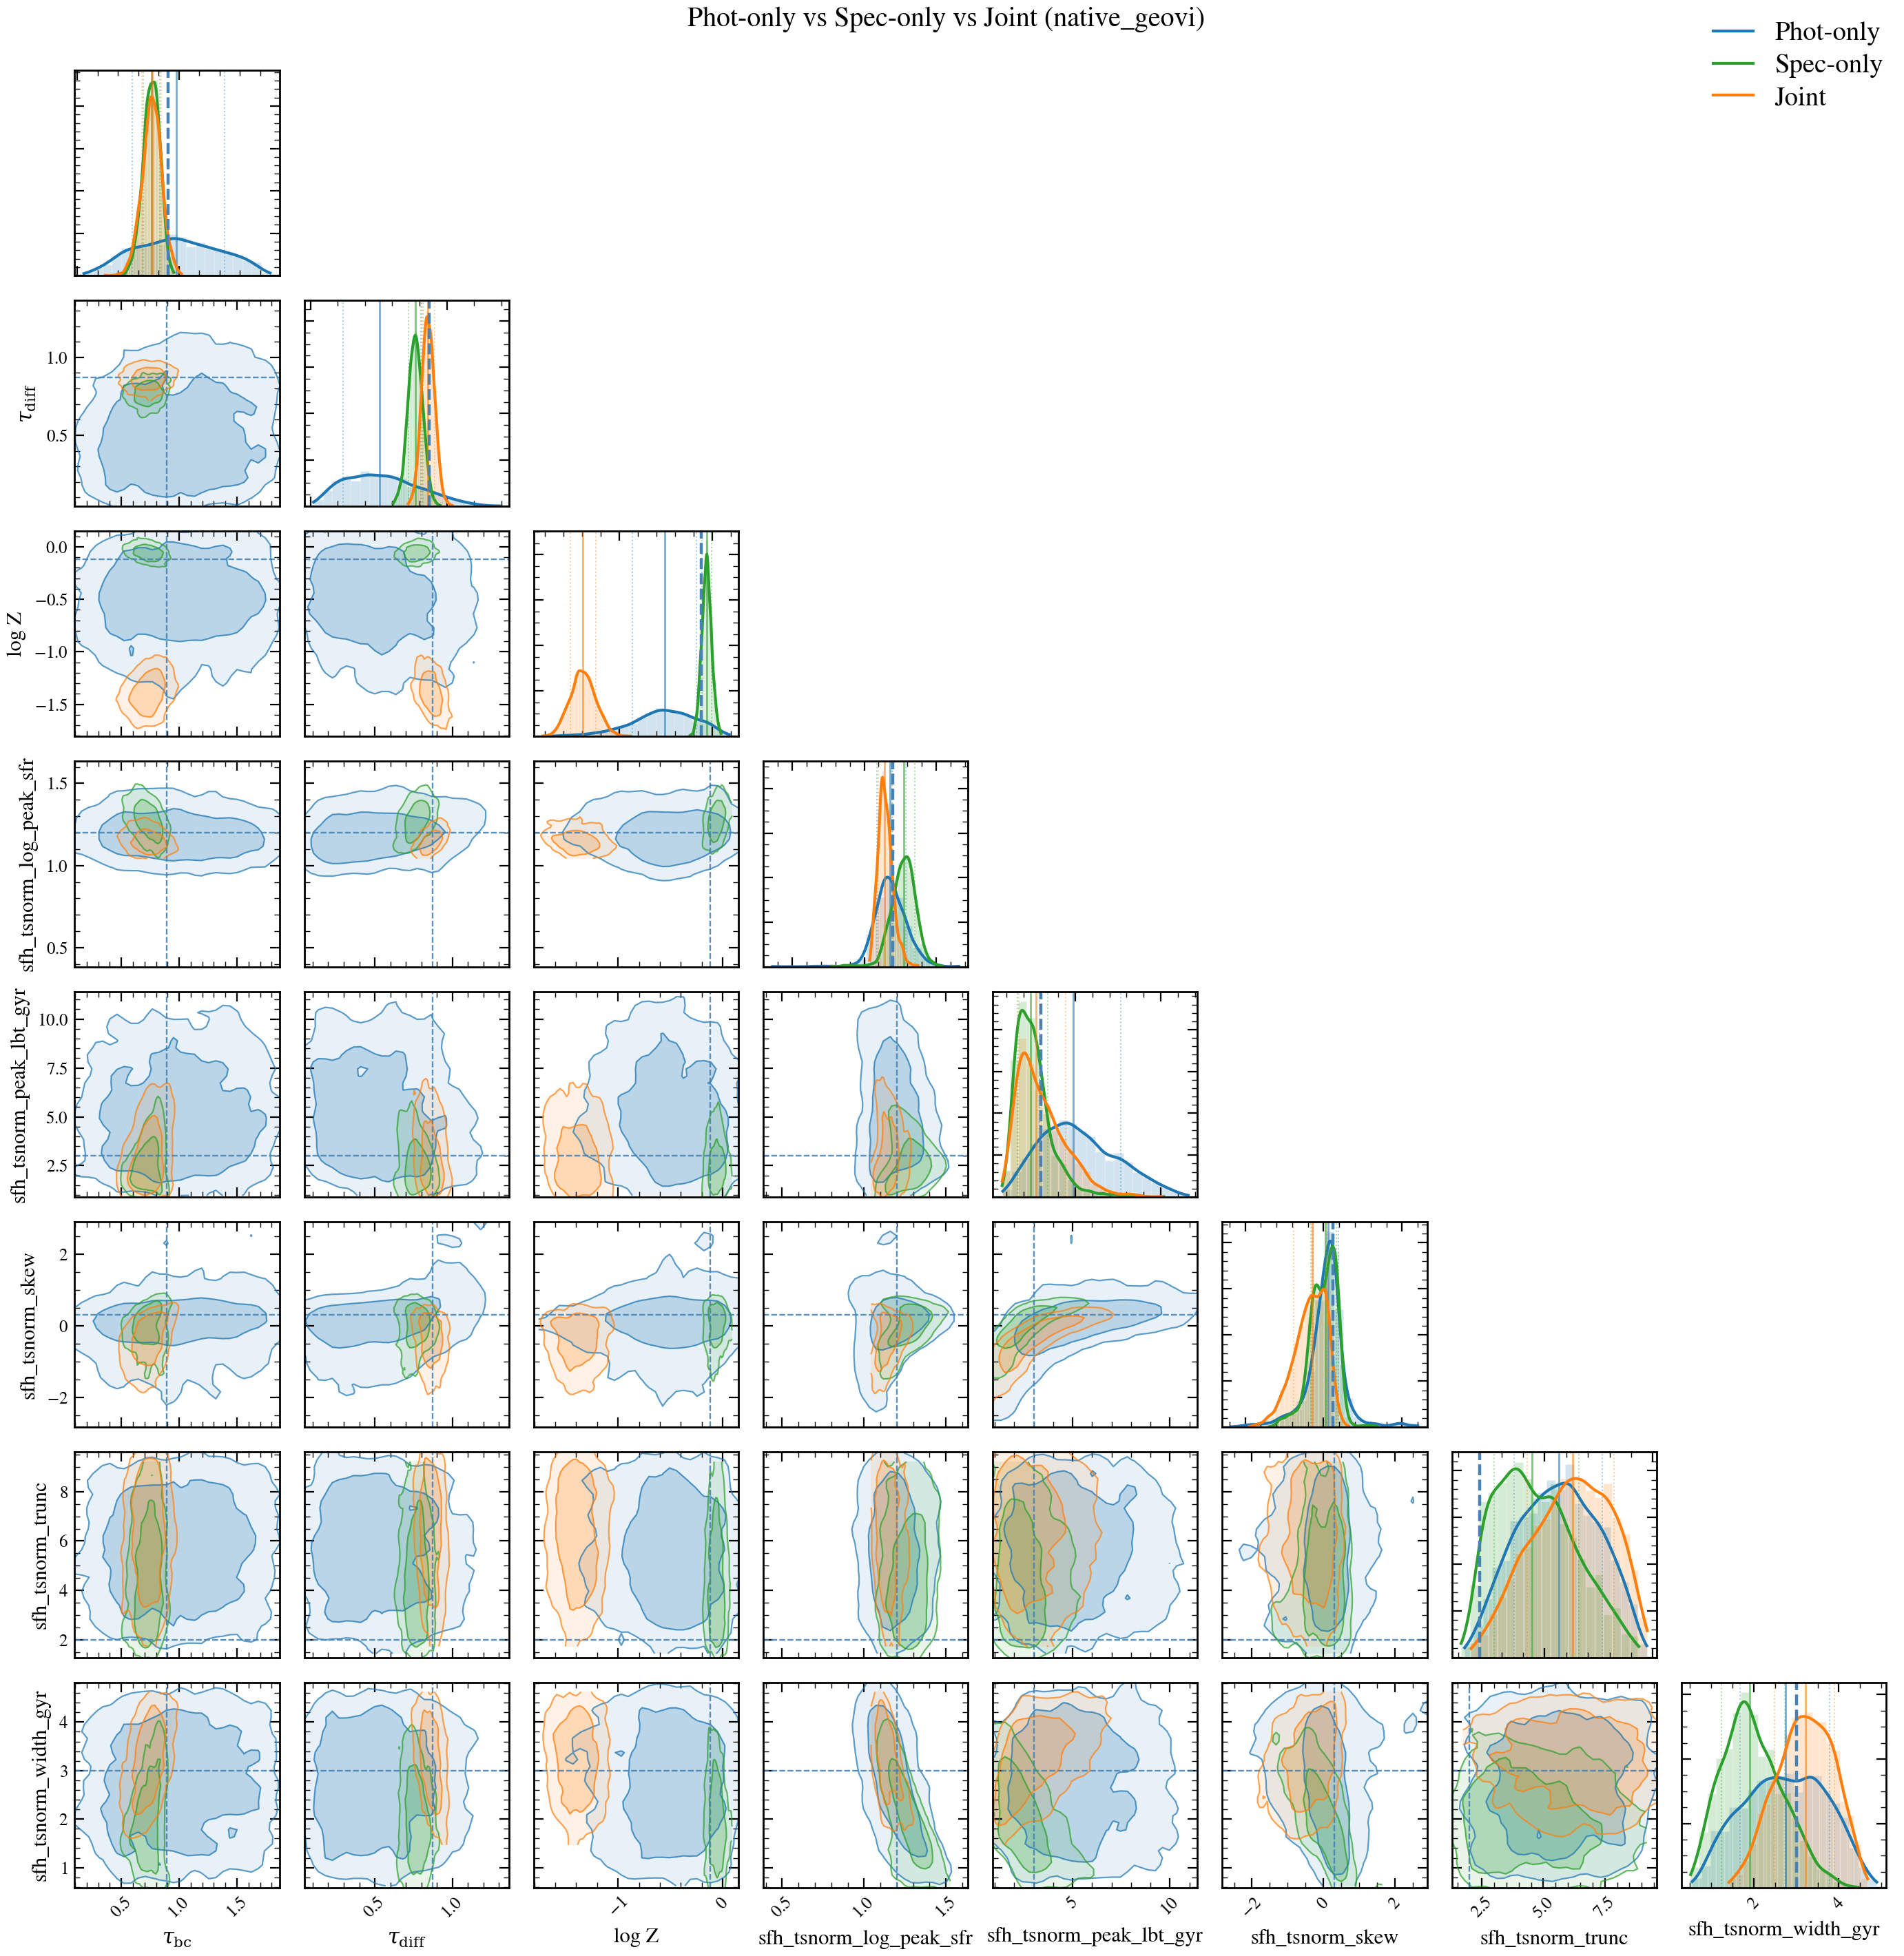

In [13]:
# --- Corner: Phot-only vs Spec-only vs Joint ---
k_phot_vi, k_spec_vi = jax.random.split(jax.random.PRNGKey(77), 2)

result_geovi_phot = fitter_phot.run(
    "vi",
    key=k_phot_vi,
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=2000,
    verbose=False,
)
result_geovi_spec = fitter_spec.run(
    "vi",
    key=k_spec_vi,
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=2000,
    verbose=False,
)

fig = plot_corner_comparison(
    [result_geovi_phot, result_geovi_spec, result_geovi],
    labels=["Phot-only", "Spec-only", "Joint"],
    colors=[COLORS["rt"], COLORS["nuts"], COLORS["geovi"]],
    truths=truths_dict,
)
if fig is not None:
    fig.suptitle("Phot-only vs Spec-only vs Joint (native_geovi)", y=1.02)
    plt.savefig(
        os.path.join(FIGDIR, "fig11_corner_data_comparison.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

In [14]:
# Convergence diagnostics
convergence_table(
    {
        "Laplace (joint)": result_laplace,
        "Pathfinder (joint)": result_pathfinder,
        "geoVI (joint)": result_geovi,
        "geoVI (phot)": result_geovi_phot,
        "geoVI (spec)": result_geovi_spec,
    }
)

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
Laplace (joint)     1576     1620      1.3        —        —         OK
Pathfinder (joint)     1475     1554      1.4        —        —         OK
geoVI (joint)       1475     1581      1.4        —        —         OK
geoVI (phot)        1368     1543      1.5        —        —         OK
geoVI (spec)        1476     1580      1.4        —        —         OK


{'Laplace (joint)': {'ess_min': 1576.241253230202,
  'ess_median': 1619.8794089152548,
  'n_params_low_ess': 0,
  'tau_max_max': 1.268841299452978,
  'tau_max_median': 1.2346720305555539,
  'n_params_short_chain': 0,
  'converged': True,
  'warnings': []},
 'Pathfinder (joint)': {'ess_min': 1474.8177570639373,
  'ess_median': 1553.9969603867808,
  'n_params_low_ess': 0,
  'tau_max_max': 1.3560997556617396,
  'tau_max_median': 1.2870940325919553,
  'n_params_short_chain': 0,
  'converged': True,
  'warnings': []},
 'geoVI (joint)': {'ess_min': 1475.2913533180442,
  'ess_median': 1580.5268608994625,
  'n_params_low_ess': 0,
  'tau_max_max': 1.3556644221508147,
  'tau_max_median': 1.2654754378281272,
  'n_params_short_chain': 0,
  'converged': True,
  'warnings': []},
 'geoVI (phot)': {'ess_min': 1368.0036532443573,
  'ess_median': 1542.8817690550031,
  'n_params_low_ess': 0,
  'tau_max_max': 1.4619843998638455,
  'tau_max_median': 1.2962761299387093,
  'n_params_short_chain': 0,
  'conve

## The pack_data / unpack_prediction Interface

The `Observation` object manages the canonical data ordering:
photometry first, then spectroscopy. Two methods handle all
concatenation and slicing.

- **`pack_data(phot=, spec=)`** validates shapes and concatenates
  into a single vector for the `Fitter`.
- **`unpack_prediction(predicted)`** splits a model prediction back
  into labeled `{"photometry": ..., "spectroscopy": ...}` arrays.

You never need to manually track index boundaries.

In [15]:
# Demonstrate pack / unpack round-trip
packed = obs.pack_data(phot=mock_phot.flux_true, spec=mock_spec.flux_true)
print(f"Packed shape: {packed.shape}  (={obs.n_data_phot} + {obs.n_data_spec})")

components = obs.unpack_prediction(packed)
print(f"Unpacked keys: {list(components.keys())}")
print(f"  photometry shape:   {components['photometry'].shape}")
print(f"  spectroscopy shape: {components['spectroscopy'].shape}")

# Verify round-trip fidelity
assert jnp.allclose(components["photometry"], mock_phot.flux_true)
assert jnp.allclose(components["spectroscopy"], mock_spec.flux_true)
print("Round-trip check passed.")

Packed shape: (205,)  (=5 + 200)
Unpacked keys: ['photometry', 'spectroscopy']
  photometry shape:   (5,)
  spectroscopy shape: (200,)


Round-trip check passed.


## When to Use Joint Fitting

| Scenario | Recommended mode | Why |
|----------|-----------------|-----|
| Only broadband photometry available | Photometry-only | Fastest; constrains mass, dust, SFR |
| Medium-resolution spectrum available | Spectroscopy-only | Breaks age-metallicity degeneracy |
| Both photometry and spectroscopy | **Joint** | Best of both: broadband shape + spectral features |
| Many galaxies, heterogeneous data | Joint where available | `Observation` per galaxy; `fit_batch` handles mixed types |

Joint fitting is especially valuable when:
- The spectrum covers only part of the SED (e.g. optical only, missing UV/NIR)
- Dust parameters are poorly constrained by spectroscopy alone
- You need precise stellar masses alongside detailed SFH recovery